# Exercise 6 and 7

### Versions

The following versions were applied in this exercise. If you get strange error messages, try to install the following versions.<br>
For example, use: `pip install tensorflow --upgrade`

- Python 3.11.2 (tags/v3.11.2:878ead1, Feb  7 2023, 16:38:35) [MSC v.1934 64 bit (AMD64)]
- numpy 1.23.5
- pandas 1.5.3
- matplotlib 3.7.1
- tensorflow 2.14.0
- keras 2.14.0

**Check** your **versions** with the **code below**.

`keras` and `tensorflow` should have the same version numbers.

In [1]:
# Check your versions in case of problems.
import sys
import pkg_resources as pkg
print("Python", sys.version)
print("numpy", pkg.get_distribution("numpy").version)
print("pandas", pkg.get_distribution("pandas").version)
print("matplotlib", pkg.get_distribution("matplotlib").version)
print("tensorflow", pkg.get_distribution("tensorflow").version)
print("keras", pkg.get_distribution("keras").version)

Python 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
numpy 1.26.0
pandas 2.1.2
matplotlib 3.8.1
tensorflow 2.14.0
keras 2.14.0


## Essential libraries
(more will be imported below) 

In [23]:
import pandas as pd

## Making some Data

In [24]:
# Quickly making some data
from random import random
from random import seed
from math import sin

seed(10)

somelist = []
for i in range(1000):
      x = random()*4
      
      y = sin(x)
      # y = sin(x) + random()*0.5-0.25 
      somelist.append([x,y]) 


In [25]:
df = pd.DataFrame(somelist)
df.columns=['x','y']
df.head()


,x,y
0,2.285610,0.755215
1,1.715556,0.989541
2,2.312365,0.737410
3,0.824393,0.734136
4,3.253285,-0.111460


In [26]:
# Let us save the data
pd.DataFrame.to_csv(df, 'Exercise_06_Data.csv', index = True)

## Getting and plotting the data


In [27]:
df = pd.read_csv('Exercise_06_Data.csv')
df.head()

,Unnamed: 0,x,y
0,0,2.285610,0.755215
1,1,1.715556,0.989541
2,2,2.312365,0.737410
3,3,0.824393,0.734136
4,4,3.253285,-0.111460


In [28]:
from matplotlib import pyplot as plt


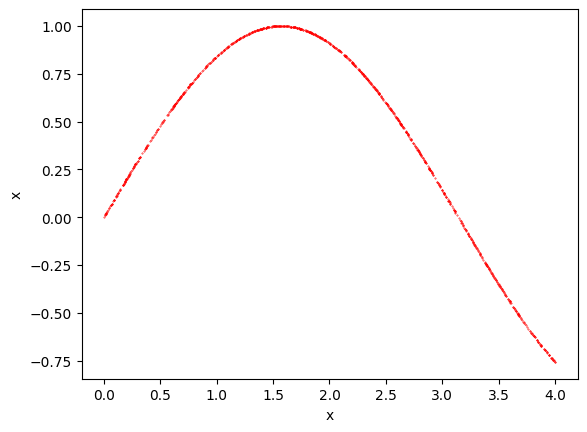

In [29]:
plt.scatter(df.x, df.y, color = 'red', marker = '.', s = 0.5)
plt.xlabel('x')
plt.ylabel('x')
plt.show()

## Data set split

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(df.x, df.y, train_size = 0.8, shuffle = True)

## Creating a network model

In [32]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping


In [33]:
model = Sequential()
model.add(Dense(4, input_dim = 1, activation = 'tanh'))
model.add(Dense(5, activation = 'tanh'))
model.add(Dense(1, activation = 'linear'))


In [34]:
model.compile(loss = 'mse', optimizer = 'adam')


Other possible activation functions:
```python
activation='sigmoid'
activation='relu'
```

Other optimizers:
```python
optimizer='sgd'
```


In [35]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 4)                 8         
                                                                 
 dense_4 (Dense)             (None, 5)                 25        
                                                                 
 dense_5 (Dense)             (None, 1)                 6         
                                                                 
Total params: 39 (156.00 Byte)
Trainable params: 39 (156.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
early_stop = EarlyStopping(monitor = 'loss', patience = 2, verbose = 1)

## Fit the model

In [38]:
model.fit(X_train, y_train, epochs = 10, batch_size = 1, callbacks = [early_stop])


Epoch 1/10
800/800 [==============================] - 1s 897us/step - loss: 1.5222e-04
Epoch 2/10
800/800 [==============================] - 1s 881us/step - loss: 1.2213e-04
Epoch 3/10
800/800 [==============================] - 1s 897us/step - loss: 1.0022e-04
Epoch 4/10
800/800 [==============================] - 1s 897us/step - loss: 9.9104e-05
Epoch 5/10
800/800 [==============================] - 1s 861us/step - loss: 9.4191e-05
Epoch 6/10
800/800 [==============================] - 1s 863us/step - loss: 6.2033e-05
Epoch 7/10
800/800 [==============================] - 1s 898us/step - loss: 7.1579e-05
Epoch 8/10
800/800 [==============================] - 1s 902us/step - loss: 6.4875e-05
Epoch 8: early stopping


## Make predictions

In [39]:
y_pred = model.predict(X_test)


7/7 [==============================] - 0s 997us/step


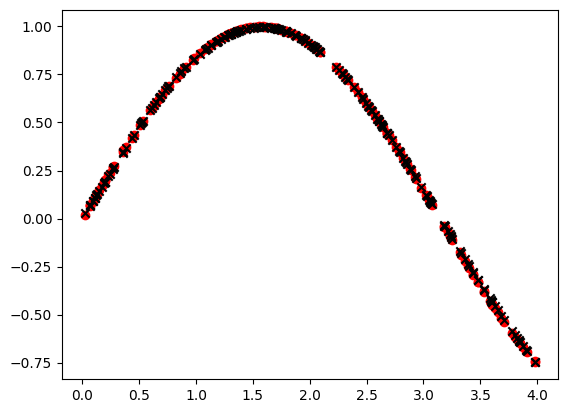

In [40]:
plt.scatter(X_test, y_test, marker = 'o', color = 'red')
plt.scatter(X_test, y_pred, marker = 'x', color = 'black')
